In [39]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datetime import timedelta, datetime
import random

from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100


## Generación de Datos Sintéticos

In [ ]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

SEED = 1234

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

NUM_DIAS = 1500
FECHA_INICIO = datetime(2024, 1, 1)

RUTAS = ["Ruta A", "Ruta B", "Ruta C", "Ruta D", "Ruta E"]

# ============================================================
# PARÁMETROS DE GENERACIÓN
# ============================================================

# --- Demanda base y tendencia ---
DEMANDA_BASE = {"Ruta A": 1200, "Ruta B": 1800, "Ruta C": 800,
                "Ruta D": 1500, "Ruta E": 1000}
TREND_DRIFT = {"Ruta A": 0.10, "Ruta B": 0.15, "Ruta C": 0.05,
               "Ruta D": 0.12, "Ruta E": 0.08}

# --- Estacionalidad semanal (base + ruido por ocurrencia) ---
# La estructura base define el patrón general, pero cada día concreto
# tiene un multiplicador ligeramente distinto (como en la vida real)
FACTOR_SEMANA_BASE = {0: 1.20, 1: 1.25, 2: 1.25, 3: 1.20, 4: 1.15,
                     5: 0.80, 6: 0.70}
WEEKLY_NOISE_STD = 0.06  # ±6% de variación día a día para el mismo día_semana

# --- Estacionalidad mensual (base + ruido) ---
FACTOR_MES_BASE = {
    1: 0.95, 2: 0.95, 3: 1.00, 4: 1.00, 5: 1.05,
    6: 1.30, 7: 1.40, 8: 1.15,
    9: 1.00, 10: 1.00, 11: 0.95, 12: 1.35
}
MONTHLY_NOISE_STD = 0.04

# --- Clima estacional con persistencia ---
# Probabilidad base por mes (sol/lluvia/nublado)
# Además, si llovió ayer, hoy es más probable que llueva
CLIMA_PROBS = {
     1: (0.60, 0.15, 0.25),  2: (0.55, 0.20, 0.25),
     3: (0.50, 0.25, 0.25),  4: (0.40, 0.35, 0.25),
     5: (0.40, 0.35, 0.25),  6: (0.50, 0.20, 0.30),
     7: (0.60, 0.10, 0.30),  8: (0.60, 0.10, 0.30),
     9: (0.50, 0.20, 0.30), 10: (0.45, 0.30, 0.25),
    11: (0.45, 0.30, 0.25), 12: (0.50, 0.20, 0.30)
}
CLIMA_OPTS = ["Soleado", "Nublado", "Lluvia"]
CLIMA_IMPACTO = {"Soleado": 1.0, "Nublado": 0.96, "Lluvia": 0.87}
LLUVIA_CONSECUTIVA_PENALTY = 0.02  # -2% extra por cada día seguido de lluvia
LLUVIA_FINDE_PENALTY = 0.06  # -6% adicional si llueve en sábado/domingo

# --- Festivos y ventanas ---
FESTIVOS = {(1, 1), (5, 1), (7, 28), (7, 29), (12, 25)}
VENTANA_FESTIVO = 2  # días antes/después con efecto de viaje
BOOST_PREPOST_FESTIVO = 0.10  # +10% en ventana festiva

# --- Día de pago (quincena / fin de mes) ---
# La demanda sube en días de cobro porque la gente hace más trámites
DIA_PAGO = {1: 0.06, 15: 0.08, 30: 0.05}

# --- Probabilidades de eventos especiales ---
PROB_EVENTO_FESTIVO = 0.35
PROB_EVENTO_FINDE = 0.04
PROB_EVENTO_NORMAL = 0.025

# --- Parámetros de ruido ---
AR_PHI = 0.6       # coeficiente autorregresivo AR(1)
AR_SIGMA = 35      # innovación del AR(1)
RUIDO_MEDICION_STD = 25  # error de medición base
RUIDO_HETERO_FACTOR = 0.015  # componente heteroscedástico
TREND_NOISE_STD = 0.04  # ruido en el incremento de tendencia

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def generar_clima(mes, historial):
    """Clima con persistencia: si llovió ayer, más probable que llueva hoy."""
    p_sol, p_lluvia, p_nublado = CLIMA_PROBS[mes]
    if len(historial) >= 2 and all(c == "Lluvia" for c in historial[-2:]):
        p_lluvia = min(0.95, p_lluvia * 1.8)
    elif historial and historial[-1] == "Lluvia":
        p_lluvia = min(0.90, p_lluvia * 1.4)
    # Rebalancear
    resto = 1.0 - p_lluvia
    p_sol = p_sol / (p_sol + p_nublado) * resto if (p_sol + p_nublado) > 0 else resto / 2
    p_nublado = 1.0 - p_lluvia - p_sol
    return random.choices(CLIMA_OPTS, weights=[p_sol, p_lluvia, p_nublado], k=1)[0]


def contar_lluvia_consecutiva(historial):
    """Días consecutivos de lluvia hasta hoy (sin incluir hoy)."""
    count = 0
    for c in reversed(historial):
        if c == "Lluvia":
            count += 1
        else:
            break
    return count


def generar_evento(festivo, dia_semana):
    """Genera eventos especiales (conciertos, cortes, festividades)."""
    if festivo:
        if random.random() < PROB_EVENTO_FESTIVO:
            return random.randint(200, 600)
    elif dia_semana >= 5 and random.random() < PROB_EVENTO_FINDE:
        return random.randint(100, 400)
    elif random.random() < PROB_EVENTO_NORMAL:
        # Eventos imprevistos: pueden ser positivos (feria) o negativos (corte)
        return random.randint(-200, 300)
    return 0


def es_festivo(fecha):
    return 1 if (fecha.month, fecha.day) in FESTIVOS else 0


# ============================================================
# PRE-CÓMPUTOS
# ============================================================

todas_fechas = [FECHA_INICIO + timedelta(days=i) for i in range(NUM_DIAS)]

# Fechas en ventana de festivo (pre/post viaje)
fechas_ventana_festivo = set()
for i, fecha in enumerate(todas_fechas):
    for offset in range(-VENTANA_FESTIVO, VENTANA_FESTIVO + 1):
        if offset == 0:
            continue
        idx = i + offset
        if 0 <= idx < len(todas_fechas):
            check = todas_fechas[idx]
            if (check.month, check.day) in FESTIVOS:
                fechas_ventana_festivo.add(fecha)
                break

# ============================================================
# GENERACIÓN
# ============================================================

print("Generando datos sintéticos...")

registros = []

for ruta in RUTAS:

    demanda_base = DEMANDA_BASE[ruta]
    drift = TREND_DRIFT[ruta]

    # --- Tendencia como random walk (crecimiento con perturbaciones) ---
    trend_inc = np.random.normal(drift, TREND_NOISE_STD, NUM_DIAS)
    trend = np.cumsum(trend_inc)

    # --- Ruido AR(1) persistente ---
    ar = np.zeros(NUM_DIAS)
    ar[0] = np.random.normal(0, AR_SIGMA / np.sqrt(1 - AR_PHI**2))
    for i in range(1, NUM_DIAS):
        ar[i] = AR_PHI * ar[i-1] + np.random.normal(0, AR_SIGMA)

    historial_clima = []

    for i in range(NUM_DIAS):

        fecha = todas_fechas[i]
        dia_semana = fecha.weekday()
        mes = fecha.month
        dia_mes = fecha.day

        # ---- 1. Factor semanal con ruido ----
        # Cada lunes no es igual al anterior
        factor_semana = FACTOR_SEMANA_BASE[dia_semana] * \
            np.random.normal(1, WEEKLY_NOISE_STD)

        # ---- 2. Factor mensual con ruido ----
        # Cada enero no es igual al anterior
        factor_mes = FACTOR_MES_BASE[mes] * \
            np.random.normal(1, MONTHLY_NOISE_STD)

        # ---- 3. Clima con persistencia e impacto ----
        clima = generar_clima(mes, historial_clima)
        historial_clima.append(clima)

        factor_clima = CLIMA_IMPACTO[clima]

        # Penalización extra por lluvia prolongada
        if clima == "Lluvia":
            cons_days = contar_lluvia_consecutiva(historial_clima[:-1])
            factor_clima *= (1 - LLUVIA_CONSECUTIVA_PENALTY * cons_days)

        # Interacción: lluvia afecta más en fin de semana
        if clima == "Lluvia" and dia_semana >= 5:
            factor_clima *= (1 - LLUVIA_FINDE_PENALTY)

        # ---- 4. Festivo y ventana festiva ----
        festivo = es_festivo(fecha)
        factor_prepost = 1.0 + BOOST_PREPOST_FESTIVO \
            if fecha in fechas_ventana_festivo else 1.0

        # ---- 5. Día de pago ----
        factor_pago = 1.0
        for dia, boost in DIA_PAGO.items():
            if dia_mes == dia:
                factor_pago = 1.0 + boost * np.random.uniform(0.5, 1.5)
                break

        # ---- 6. Eventos especiales ----
        evento = generar_evento(festivo, dia_semana)

        # ---- 7. Ruido de medición heteroscedástico ----
        # A mayor demanda absoluta, mayor varianza
        ruido_base = np.random.normal(0, RUIDO_MEDICION_STD)
        ruido_hetero = np.random.normal(0, demanda_base * RUIDO_HETERO_FACTOR)
        ruido_total = ruido_base + ruido_hetero

        # ---- Demanda final ----
        pasajeros = (
            demanda_base
            * factor_semana
            * factor_mes
            * factor_clima
            * factor_prepost
            * factor_pago
            + trend[i]
            + evento
            + ar[i]
            + ruido_total
        )
        pasajeros = max(50, int(round(pasajeros)))

        # ---- Viajes: relación con pasajeros ----
        cap_vehiculo = random.randint(25, 50)
        viajes = max(1, int(round(pasajeros / cap_vehiculo)))

        registros.append({
            "fecha": fecha.strftime("%Y-%m-%d"),
            "ruta": ruta,
            "pasajeros": pasajeros,
            "viajes": viajes,
            "dia_semana": dia_semana,
            "mes": mes,
            "festivo": festivo,
            "clima": clima
        })

df = pd.DataFrame(registros)

print(df.head())
print(f"\nTotal registros: {len(df)}")

df.to_csv("demanda_transporte.csv", index=False)
print("\nDataset sintético guardado como: demanda_transporte.csv")

print("\n" + "=" * 60)
print("RESUMEN ESTADÍSTICO")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("PASAJEROS PROMEDIO POR RUTA")
print("=" * 60)
print(df.groupby("ruta")["pasajeros"].mean().sort_values(ascending=False))


Generando datos sintéticos...
        fecha    ruta  pasajeros  viajes  dia_semana  mes  festivo    clima
0  2024-01-01  Ruta A       1234      49           0    1        1   Lluvia
1  2024-01-02  Ruta A       1835      37           1    1        0  Soleado
2  2024-01-03  Ruta A       1614      60           2    1        0  Soleado
3  2024-01-04  Ruta A       1544      62           3    1        0  Soleado
4  2024-01-05  Ruta A       1574      44           4    1        0  Soleado

Total registros: 7500

Dataset sintético guardado como: demanda_transporte.csv

RESUMEN ESTADÍSTICO
         pasajeros       viajes   dia_semana          mes      festivo
count  7500.000000  7500.000000  7500.000000  7500.000000  7500.000000
mean   1507.357600    41.965600     2.996667     6.384667     0.014000
std     596.533764    19.222406     2.000964     3.508039     0.117498
min     346.000000     7.000000     0.000000     1.000000     0.000000
25%    1055.000000    28.000000     1.000000     3.000000 

## Análisis Exploratorio de Datos (EDA)

VISUALIZACIONES EXPLORATORIAS


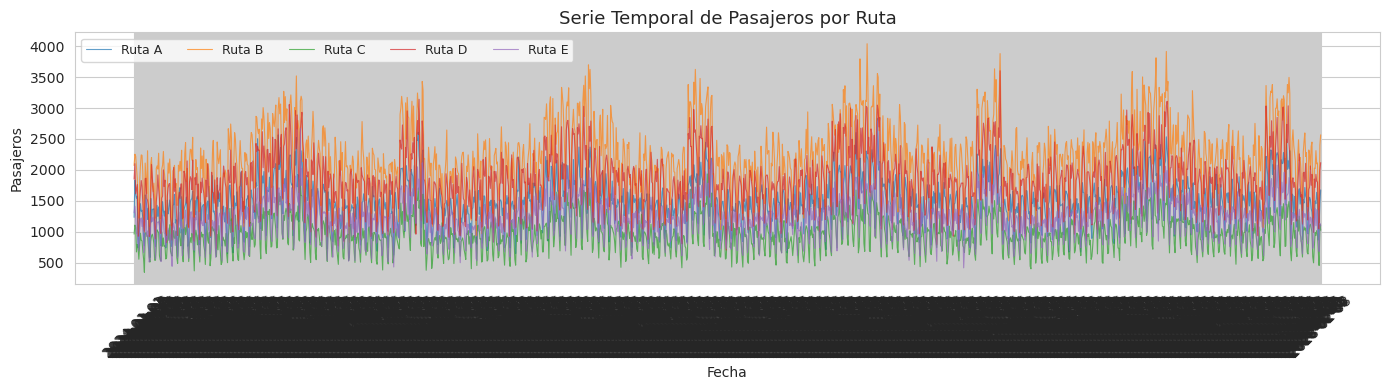

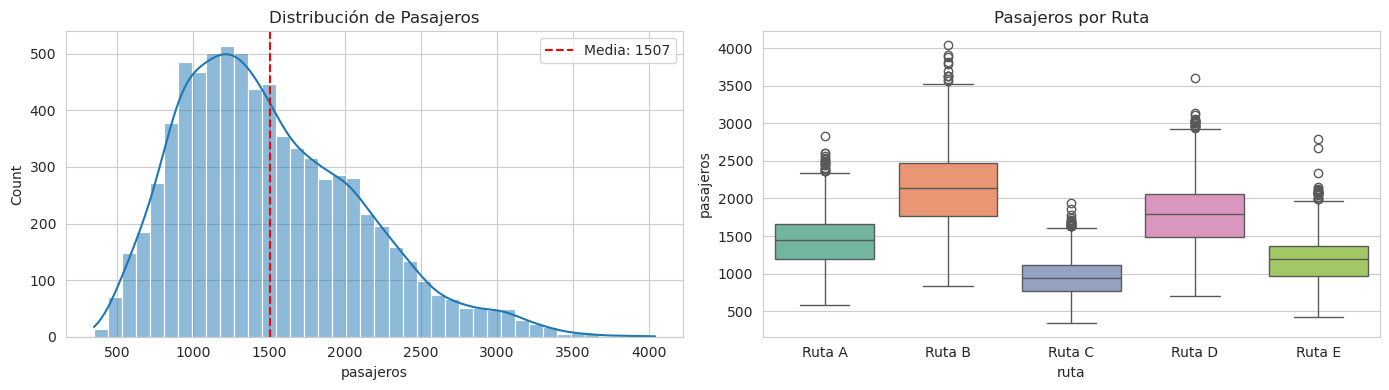

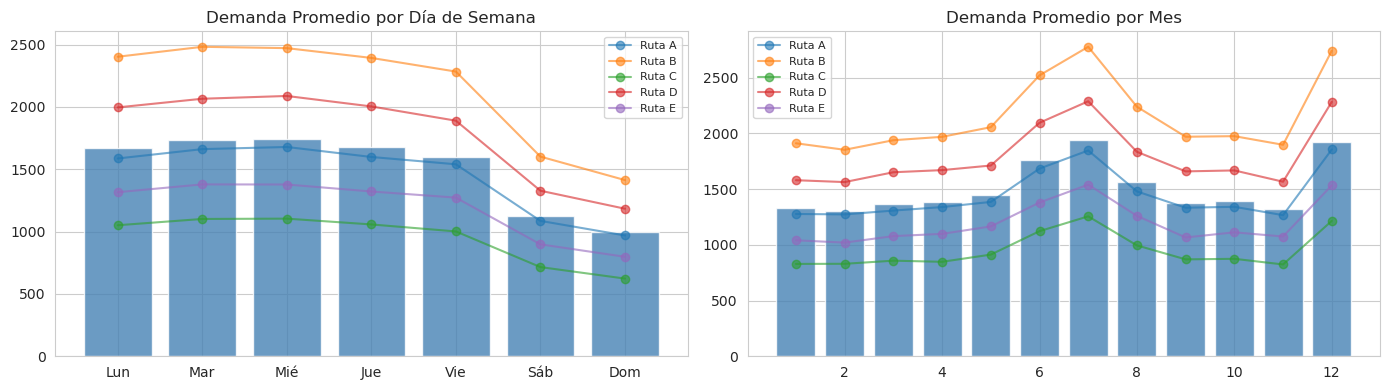

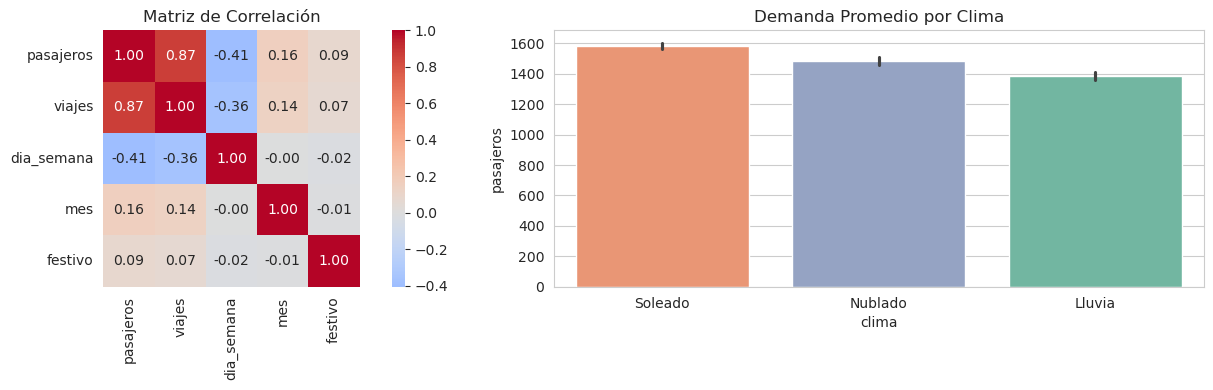

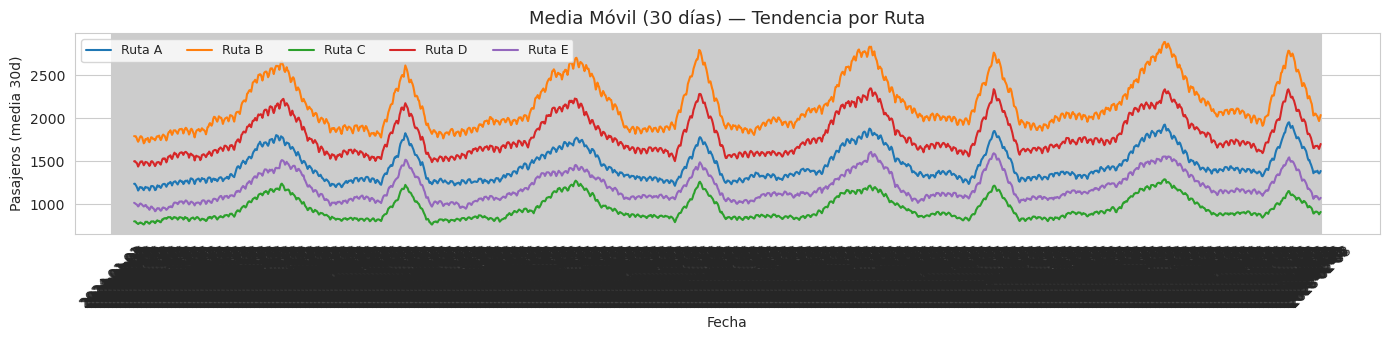


✓ EDA completado — 5 gráficos generados


In [41]:
print("=" * 60)
print("VISUALIZACIONES EXPLORATORIAS")
print("=" * 60)

# ---------------------------------------------------------
# 1. Serie temporal completa
# ---------------------------------------------------------
plt.figure(figsize=(14, 4))
for ruta in df["ruta"].unique():
    sub = df[df["ruta"] == ruta].sort_values("fecha")
    plt.plot(sub["fecha"], sub["pasajeros"], label=ruta, alpha=0.7, linewidth=0.8)
plt.title("Serie Temporal de Pasajeros por Ruta", fontsize=13)
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.legend(ncol=5, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Distribución + Boxplot
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["pasajeros"], kde=True, bins=40, ax=axes[0])
axes[0].axvline(df["pasajeros"].mean(), color="red", ls="--", label=f"Media: {df['pasajeros'].mean():.0f}")
axes[0].set_title("Distribución de Pasajeros")
axes[0].legend()

sns.boxplot(x="ruta", y="pasajeros", hue="ruta", data=df, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Pasajeros por Ruta")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Patrón semanal y mensual
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weekly = df.groupby("dia_semana")["pasajeros"].mean()
axes[0].bar(range(7), weekly.values, color="steelblue", alpha=0.8)
for ruta in df["ruta"].unique():
    sub = df[df["ruta"] == ruta].groupby("dia_semana")["pasajeros"].mean()
    axes[0].plot(range(7), sub.values, marker="o", label=ruta, alpha=0.6)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
axes[0].set_title("Demanda Promedio por Día de Semana")
axes[0].legend(fontsize=8)

monthly = df.groupby("mes")["pasajeros"].mean()
axes[1].bar(range(1, 13), monthly.values, color="steelblue", alpha=0.8)
for ruta in df["ruta"].unique():
    sub = df[df["ruta"] == ruta].groupby("mes")["pasajeros"].mean()
    axes[1].plot(range(1, 13), sub.values, marker="o", label=ruta, alpha=0.6)
axes[1].set_title("Demanda Promedio por Mes")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Correlaciones + Clima
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

corr = df[["pasajeros", "viajes", "dia_semana", "mes", "festivo"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, ax=axes[0])
axes[0].set_title("Matriz de Correlación")

sns.barplot(x="clima", y="pasajeros", hue="clima", data=df, ax=axes[1], palette="Set2", legend=False,
            order=["Soleado", "Nublado", "Lluvia"])
axes[1].set_title("Demanda Promedio por Clima")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Media móvil 30 días (tendencia suavizada)
# ---------------------------------------------------------
plt.figure(figsize=(14, 3.5))
for ruta in df["ruta"].unique():
    sub = df[df["ruta"] == ruta].sort_values("fecha")
    plt.plot(sub["fecha"], sub["pasajeros"].rolling(30).mean(), label=ruta)
plt.title("Media Móvil (30 días) — Tendencia por Ruta", fontsize=13)
plt.xlabel("Fecha")
plt.ylabel("Pasajeros (media 30d)")
plt.legend(ncol=5, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ EDA completado — 5 gráficos generados")


## Preprocesamiento

In [42]:
# ============================================================
# CARGA Y ORDENAMIENTO
# ============================================================

df = pd.read_csv("demanda_transporte.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["ruta", "fecha"]).reset_index(drop=True)

# ============================================================
# CODIFICACIÓN DE CATEGÓRICAS
# ============================================================

route_encoder = LabelEncoder()
clima_encoder = LabelEncoder()

df["route_id"] = route_encoder.fit_transform(df["ruta"])
df["clima_id"] = clima_encoder.fit_transform(df["clima"])

print("Rutas:", dict(zip(route_encoder.classes_, range(len(route_encoder.classes_)))))
print("Climas:", dict(zip(clima_encoder.classes_, range(len(clima_encoder.classes_)))))

# ============================================================
# SPLIT TEMPORAL CORRECTO (80/20 por ruta)
# ============================================================

def split_por_ruta(df, pct_train=0.80):
    """
    Split temporal respetando la secuencia cronológica por ruta.
    Garantiza que el corte sea reproducible y que test siempre
    tenga datos (mínimo 20% por ruta).
    """
    trains, tests = [], []

    for ruta in df["ruta"].unique():
        sub = df[df["ruta"] == ruta].sort_values("fecha")
        n = len(sub)
        corte = int(n * pct_train)

        trains.append(sub.iloc[:corte])
        tests.append(sub.iloc[corte:])

    train_df = pd.concat(trains).reset_index(drop=True)
    test_df  = pd.concat(tests).reset_index(drop=True)

    return train_df, test_df


train_df, test_df = split_por_ruta(df, pct_train=0.80)

print(f"\nTrain: {len(train_df)} registros")
print(f"Test:  {len(test_df)}  registros")
print(f"Rango train: {train_df['fecha'].min().date()} → {train_df['fecha'].max().date()}")
print(f"Rango test:  {test_df['fecha'].min().date()}  → {test_df['fecha'].max().date()}")

# ============================================================
# ESCALADO CORRECTO: features y target por separado
# ============================================================

# Target con su propio scaler para desnormalizar limpiamente
# Features continuas — excluye pasajeros (se escala aparte)
FEATURE_COLS_SIN_TARGET = ["dia_semana", "mes", "festivo"]
TARGET_COL = "pasajeros"

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit SOLO en train
train_df[FEATURE_COLS_SIN_TARGET] = feature_scaler.fit_transform(
    train_df[FEATURE_COLS_SIN_TARGET]
)
train_df[[TARGET_COL]] = target_scaler.fit_transform(
    train_df[[TARGET_COL]]
)

# Transform en test (sin re-fit)
test_df[FEATURE_COLS_SIN_TARGET] = feature_scaler.transform(
    test_df[FEATURE_COLS_SIN_TARGET]
)
test_df[[TARGET_COL]] = target_scaler.transform(
    test_df[[TARGET_COL]]
)

# FEATURE_COLS final para build_sequences
FEATURE_COLS = FEATURE_COLS_SIN_TARGET + [TARGET_COL]

print(f"\nFeature scaler — min: {feature_scaler.data_min_}, max: {feature_scaler.data_max_}")
print(f"Target scaler  — min: {target_scaler.data_min_[0]:.2f}, max: {target_scaler.data_max_[0]:.2f}")

# ============================================================
# PERSISTIR ARTEFACTOS
# ============================================================

import os
import joblib

os.makedirs("demand_prediction", exist_ok=True)

joblib.dump(feature_scaler, "demand_prediction/feature_scaler.pkl")
joblib.dump(target_scaler,  "demand_prediction/target_scaler.pkl")
joblib.dump(route_encoder,  "demand_prediction/route_encoder.pkl")
joblib.dump(clima_encoder,  "demand_prediction/clima_encoder.pkl")

print("\n✓ Artefactos guardados en demand_prediction/")

# ============================================================
# CONSTRUCCIÓN DE SECUENCIAS
# ============================================================

SEQ_LENGTH = 30


def build_sequences(df, feature_cols, seq_length):
    """
    Construye ventanas deslizantes de longitud seq_length.
    X      → (N, seq_length, n_features)
    routes → (N,)  route_id del paso objetivo
    climas → (N,)  clima_id del paso objetivo
    y      → (N,)  pasajeros normalizados del paso objetivo
    """
    X, routes, climas, y = [], [], [], []

    for route_id in df["route_id"].unique():
        rdf = df[df["route_id"] == route_id].sort_values("fecha")
        feats     = rdf[feature_cols].values
        clima_ids = rdf["clima_id"].values
        targets   = rdf[TARGET_COL].values

        for i in range(len(rdf) - seq_length):
            X.append(feats[i : i + seq_length])
            routes.append(route_id)
            climas.append(clima_ids[i + seq_length])
            y.append(targets[i + seq_length])

    return (
        np.array(X),
        np.array(routes),
        np.array(climas),
        np.array(y),
    )


X_train, routes_train, climas_train, y_train = build_sequences(
    train_df, FEATURE_COLS, SEQ_LENGTH
)
X_test, routes_test, climas_test, y_test = build_sequences(
    test_df, FEATURE_COLS, SEQ_LENGTH
)

print(f"\nSecuencias train: {X_train.shape}")
print(f"Secuencias test:  {X_test.shape}")

# ============================================================
# DATASET Y DATALOADER
# ============================================================


class TransportDataset(Dataset):
    """Dataset para series de tiempo de transporte.
    Retorna (features, route_id, clima_id, target)."""

    def __init__(self, X, routes, climas, y):
        self.X      = torch.tensor(X,      dtype=torch.float32)
        self.routes = torch.tensor(routes, dtype=torch.long)
        self.climas = torch.tensor(climas, dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.routes[idx], self.climas[idx], self.y[idx]


def seed_worker(worker_id):
    """Fija semilla por worker para reproducibilidad total."""
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


g = torch.Generator()
g.manual_seed(SEED)

BATCH_SIZE = 32

train_dataset = TransportDataset(X_train, routes_train, climas_train, y_train)
test_dataset  = TransportDataset(X_test,  routes_test,  climas_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"\nBatchs train: {len(train_loader)}")
print(f"Batchs test:  {len(test_loader)}")

Rutas: {'Ruta A': 0, 'Ruta B': 1, 'Ruta C': 2, 'Ruta D': 3, 'Ruta E': 4}
Climas: {'Lluvia': 0, 'Nublado': 1, 'Soleado': 2}

Train: 6000 registros
Test:  1500  registros
Rango train: 2024-01-01 → 2027-04-14
Rango test:  2027-04-15  → 2028-02-08

Feature scaler — min: [0. 1. 0.], max: [ 6. 12.  1.]
Target scaler  — min: 346.00, max: 4039.00

✓ Artefactos guardados en demand_prediction/

Secuencias train: (5850, 30, 4)
Secuencias test:  (1350, 30, 4)

Batchs train: 183
Batchs test:  43


## Modelo LSTM

In [43]:
class TransportLSTM(nn.Module):
    """LSTM con embeddings de ruta y clima.

    Las features continuas (pasajeros, dia_semana, mes, festivo)
    alimentan el LSTM. Las variables categóricas (ruta, clima)
    se aprenden como embeddings y se concatenan al output del LSTM.
    """

    def __init__(
        self,
        num_routes,
        num_climas,
        input_size=4,
        hidden_size=128,
        num_layers=2,
        route_embedding_dim=8,
        clima_embedding_dim=4,
        dropout=0.2,
    ):
        super().__init__()

        self.route_embedding = nn.Embedding(num_routes, route_embedding_dim)
        self.clima_embedding = nn.Embedding(num_climas, clima_embedding_dim)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        fc_input = hidden_size + route_embedding_dim + clima_embedding_dim

        self.fc = nn.Sequential(
            nn.Linear(fc_input, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, route_ids, clima_ids):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]

        route_embed = self.route_embedding(route_ids)
        clima_embed = self.clima_embedding(clima_ids)

        combined = torch.cat([lstm_out, route_embed, clima_embed], dim=1)
        return self.fc(combined)


## Entrenamiento

Device: cpu
Parámetros: 209,845
Epoch [ 1/50]  Train: 0.0144  Val: 0.0085  LR: 1.00e-03
Epoch [ 2/50]  Train: 0.0062  Val: 0.0054  LR: 1.00e-03
Epoch [ 3/50]  Train: 0.0039  Val: 0.0033  LR: 1.00e-03
Epoch [ 4/50]  Train: 0.0033  Val: 0.0026  LR: 1.00e-03
Epoch [ 5/50]  Train: 0.0029  Val: 0.0027  LR: 1.00e-03
Epoch [ 6/50]  Train: 0.0028  Val: 0.0027  LR: 1.00e-03
Epoch [ 7/50]  Train: 0.0027  Val: 0.0024  LR: 1.00e-03
Epoch [ 8/50]  Train: 0.0028  Val: 0.0031  LR: 1.00e-03
Epoch [ 9/50]  Train: 0.0026  Val: 0.0024  LR: 1.00e-03
Epoch [10/50]  Train: 0.0026  Val: 0.0026  LR: 1.00e-03
Epoch [11/50]  Train: 0.0026  Val: 0.0033  LR: 1.00e-03
Epoch [12/50]  Train: 0.0025  Val: 0.0029  LR: 1.00e-03
Epoch [13/50]  Train: 0.0025  Val: 0.0026  LR: 1.00e-03
Epoch [14/50]  Train: 0.0025  Val: 0.0026  LR: 1.00e-03
Epoch [15/50]  Train: 0.0025  Val: 0.0023  LR: 1.00e-03
Epoch [16/50]  Train: 0.0025  Val: 0.0025  LR: 1.00e-03
Epoch [17/50]  Train: 0.0025  Val: 0.0025  LR: 1.00e-03
Epoch [18/50]  T

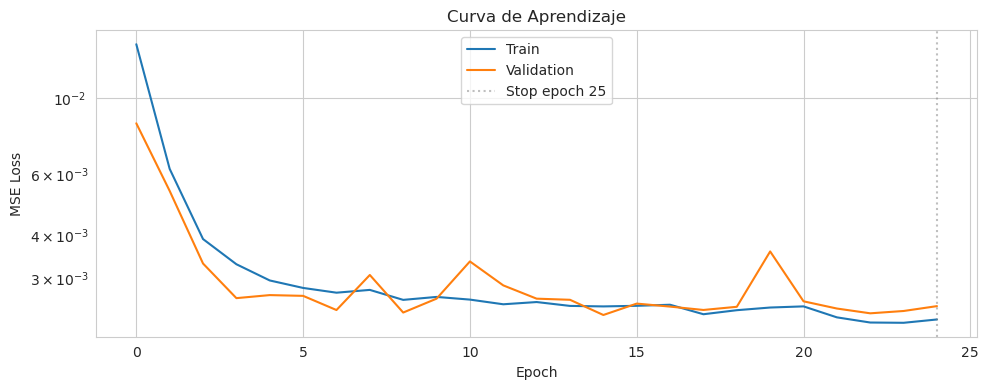

In [44]:
# ============================================================
# REPRODUCIBILIDAD
# ============================================================

import os

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 50
LR = 0.001
PATIENCE = 10
CLIP_NORM = 1.0

print(f"Device: {DEVICE}")

# ============================================================
# MODELO
# ============================================================

model = TransportLSTM(
    num_routes=len(route_encoder.classes_),
    num_climas=len(clima_encoder.classes_),
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5
)

print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# TRAIN + VALIDACIÓN
# ============================================================

best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "lr": []}

for epoch in range(EPOCHS):

    # --- Training ---
    model.train()
    train_loss = 0.0

    for X_batch, routes_batch, climas_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        routes_batch = routes_batch.to(DEVICE)
        climas_batch = climas_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(X_batch, routes_batch, climas_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)

        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- Validación ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, routes_batch, climas_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            routes_batch = routes_batch.to(DEVICE)
            climas_batch = climas_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = model(X_batch, routes_batch, climas_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
        f"Train: {avg_train_loss:.4f}  "
        f"Val: {avg_val_loss:.4f}  "
        f"LR: {current_lr:.2e}"
    )

    # --- Scheduler ---
    scheduler.step(avg_val_loss)

    # --- Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        if not os.path.exists("demand_prediction"):
            os.mkdir("demand_prediction")

        torch.save(model.state_dict(), "demand_prediction/best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping en epoch {epoch+1}")
            break

# ============================================================
# EVALUACIÓN FINAL
# ============================================================

model.load_state_dict(torch.load("demand_prediction/best_model.pth", weights_only=True))
model.eval()

predictions, reals = [], []

with torch.no_grad():
    for X_batch, routes_batch, climas_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        routes_batch = routes_batch.to(DEVICE)
        climas_batch = climas_batch.to(DEVICE)

        outputs = model(X_batch, routes_batch, climas_batch)
        predictions.extend(outputs.cpu().numpy())
        reals.extend(y_batch.numpy())

predictions = np.array(predictions)
reals = np.array(reals)

rmse = np.sqrt(mean_squared_error(reals, predictions))
mae = mean_absolute_error(reals, predictions)

print(f"\n{'=' * 40}")
print("RESULTADOS")
print(f"{'=' * 40}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")

# ---------------------------------------------------------
# Curva de aprendizaje
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train", linewidth=1.5)
plt.plot(history["val_loss"], label="Validation", linewidth=1.5)
plt.axvline(len(history["train_loss"]) - 1, color="gray", ls=":", alpha=0.5,
            label=f"Stop epoch {len(history['train_loss'])}")
plt.title("Curva de Aprendizaje")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()


Dispositivo: cpu

Secuencias test futuras: (1500, 30, 4)
Batchs test: 47

✓ Modelo cargado correctamente

      MÉTRICAS DE EVALUACIÓN POR RUTA
Ruta                RMSE         MAE      MAPE (%)
------------------------------------------------------------
Ruta A            151.04      119.34          8.47%
Ruta B            213.37      161.85          7.59%
Ruta C            120.07       94.36         10.33%
Ruta D            176.55      132.15          7.36%
Ruta E            125.12      100.36          8.86%
------------------------------------------------------------
GLOBAL            160.99      121.61          8.52%

Tabla resumen:
  ruta  route_id       rmse        mae      mape
Ruta A         0 151.041708 119.341859  8.471714
Ruta B         1 213.373878 161.854470  7.585325
Ruta C         2 120.066355  94.355838 10.327868
Ruta D         3 176.551292 132.145363  7.356305
Ruta E         4 125.116912 100.357099  8.859243


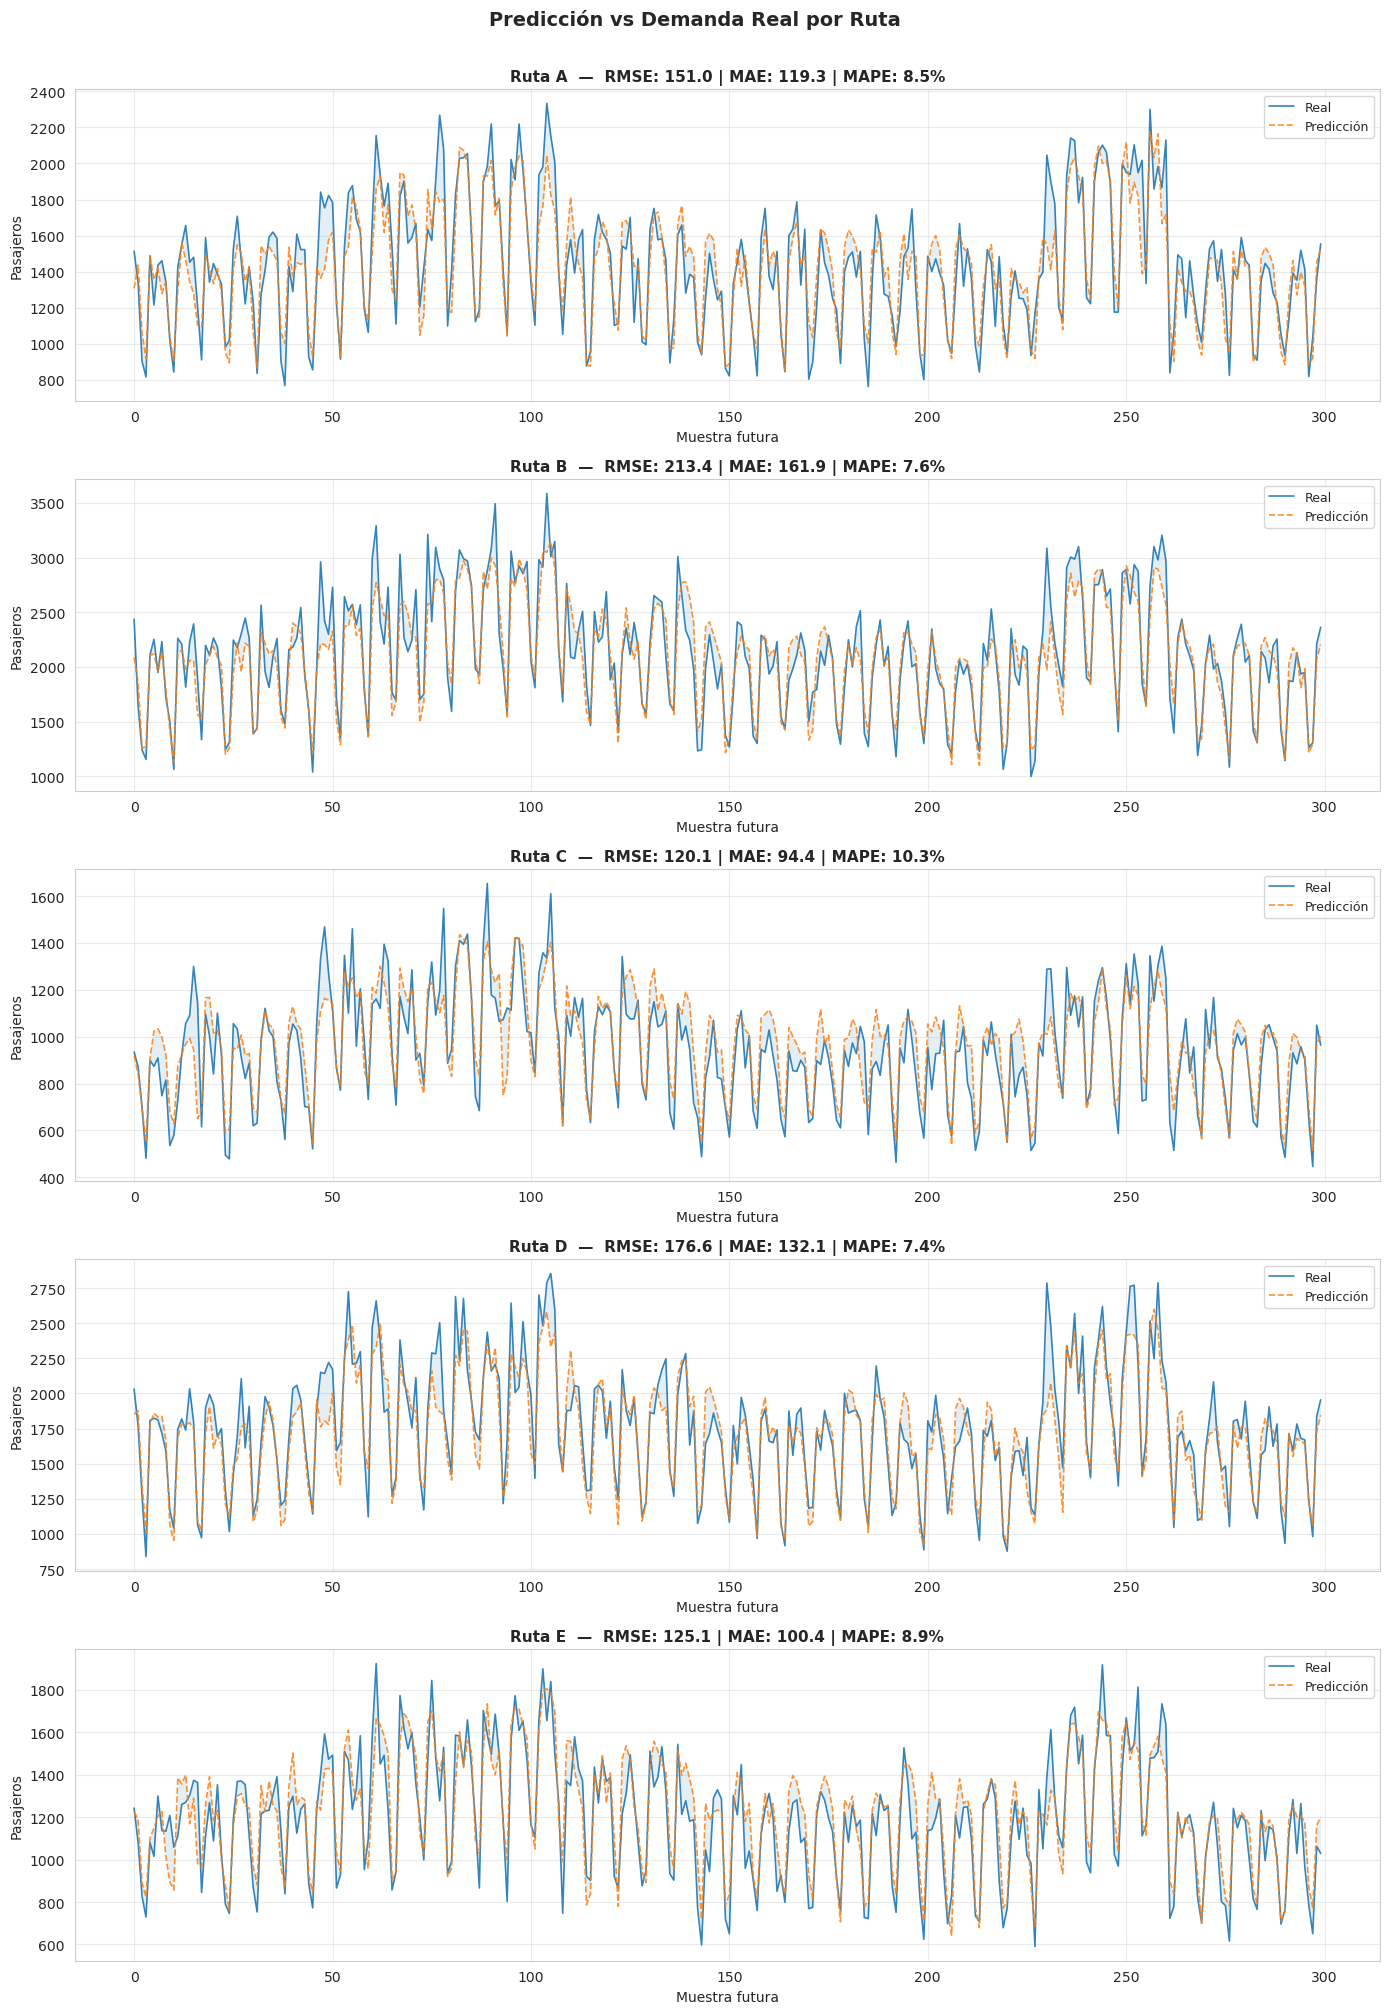


✓ Gráfica guardada: prediccion_vs_real_por_ruta.png


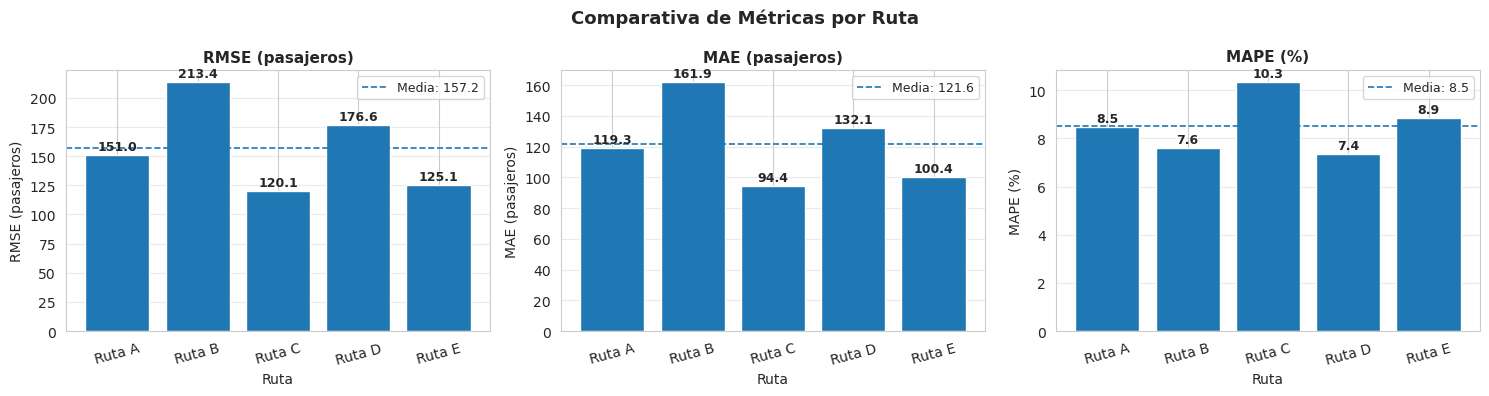

✓ Gráfica guardada: comparativa_metricas_por_ruta.png


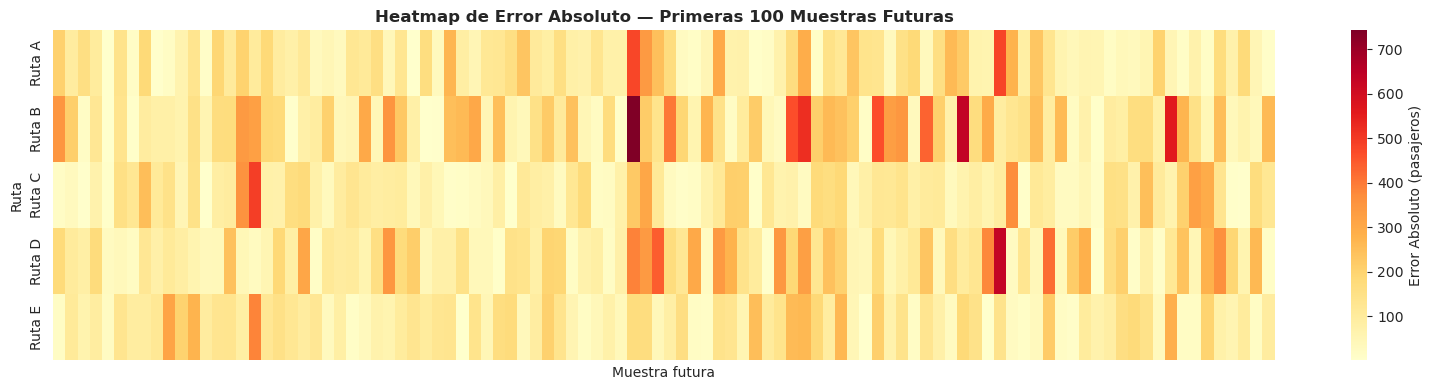

✓ Gráfica guardada: heatmap_error_por_ruta.png

✓ Evaluación por ruta completada.


In [45]:
# ============================================================
# EVALUACIÓN DEL MODELO (Forecasting Futuro Real)
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dispositivo: {DEVICE}")

# ============================================================
# FUNCIÓN: construir secuencias futuras
# ============================================================

def build_future_test_sequences(
    train_df,
    test_df,
    feature_cols,
    seq_length
):
    """
    Construye secuencias para forecasting real.

    Cada predicción futura usa:
    - contexto histórico del train
    - target ubicado en el futuro (test)

    Esto evita leakage temporal y simula producción real.
    """

    X, routes, climas, y = [], [], [], []

    for route_id in train_df["route_id"].unique():

        train_route = train_df[
            train_df["route_id"] == route_id
        ].sort_values("fecha")

        test_route = test_df[
            test_df["route_id"] == route_id
        ].sort_values("fecha")

        # si no hay futuro para esta ruta
        if len(test_route) == 0:
            continue

        # unir histórico + futuro
        combined = pd.concat(
            [train_route, test_route],
            ignore_index=True
        )

        feats = combined[feature_cols].values
        clima_ids = combined["clima_id"].values
        targets = combined["pasajeros"].values

        split_idx = len(train_route)

        # targets únicamente en el futuro
        for i in range(split_idx, len(combined)):

            start = i - seq_length

            # no hay suficiente historial
            if start < 0:
                continue

            X.append(feats[start:i])
            routes.append(route_id)
            climas.append(clima_ids[i])
            y.append(targets[i])

    return (
        np.array(X),
        np.array(routes),
        np.array(climas),
        np.array(y),
    )


# ============================================================
# CONSTRUIR TEST FUTURO
# ============================================================

X_test, routes_test, climas_test, y_test = build_future_test_sequences(
    train_df,
    test_df,
    FEATURE_COLS,
    SEQ_LENGTH
)

print(f"\nSecuencias test futuras: {X_test.shape}")

if len(X_test) == 0:
    raise ValueError(
        f"No hay suficientes datos futuros para "
        f"crear secuencias de longitud {SEQ_LENGTH}."
    )


# ============================================================
# DATASET Y DATALOADER
# ============================================================

test_dataset = TransportDataset(
    X_test,
    routes_test,
    climas_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Batchs test: {len(test_loader)}")


# ============================================================
# CARGAR MODELO
# ============================================================

model = TransportLSTM(
    num_routes=len(route_encoder.classes_),
    num_climas=len(clima_encoder.classes_),
).to(DEVICE)

weights = torch.load(
    "demand_prediction/best_model.pth",
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(weights)

model.eval()

print("\n✓ Modelo cargado correctamente")


# ============================================================
# INFERENCIA
# ============================================================

all_preds = []
all_reals = []
all_routes = []

with torch.no_grad():

    for X_batch, routes_batch, climas_batch, y_batch in test_loader:

        X_batch = X_batch.to(DEVICE)
        routes_batch = routes_batch.to(DEVICE)
        climas_batch = climas_batch.to(DEVICE)

        outputs = model(
            X_batch,
            routes_batch,
            climas_batch
        )

        all_preds.extend(
            outputs.cpu().numpy().flatten()
        )

        all_reals.extend(
            y_batch.numpy().flatten()
        )

        all_routes.extend(
            routes_batch.cpu().numpy().flatten()
        )


all_preds = np.array(all_preds)
all_reals = np.array(all_reals)
all_routes = np.array(all_routes)


# ============================================================
# DESNORMALIZAR
# ============================================================

pas_min = scaler.data_min_[0]
pas_max = scaler.data_max_[0]

preds_real = (
    all_preds * (pas_max - pas_min)
    + pas_min
)

reals_real = (
    all_reals * (pas_max - pas_min)
    + pas_min
)


# ============================================================
# MÉTRICAS POR RUTA
# ============================================================

resultados = []

print("\n" + "=" * 60)
print("      MÉTRICAS DE EVALUACIÓN POR RUTA")
print("=" * 60)

print(
    f"{'Ruta':<12}"
    f"{'RMSE':>12}"
    f"{'MAE':>12}"
    f"{'MAPE (%)':>14}"
)

print("-" * 60)

for route_id in sorted(np.unique(all_routes)):

    mask = all_routes == route_id

    y_r = reals_real[mask]
    y_p = preds_real[mask]

    rmse = np.sqrt(
        mean_squared_error(y_r, y_p)
    )

    mae = mean_absolute_error(y_r, y_p)

    mape = np.mean(
        np.abs((y_r - y_p) / (y_r + 1e-8))
    ) * 100

    nombre_ruta = route_encoder.inverse_transform(
        [route_id]
    )[0]

    print(
        f"{nombre_ruta:<12}"
        f"{rmse:>12.2f}"
        f"{mae:>12.2f}"
        f"{mape:>14.2f}%"
    )

    resultados.append({
        "ruta": nombre_ruta,
        "route_id": route_id,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "y_real": y_r,
        "y_pred": y_p,
    })


# ============================================================
# MÉTRICAS GLOBALES
# ============================================================

rmse_global = np.sqrt(
    mean_squared_error(reals_real, preds_real)
)

mae_global = mean_absolute_error(
    reals_real,
    preds_real
)

mape_global = np.mean(
    np.abs(
        (reals_real - preds_real)
        / (reals_real + 1e-8)
    )
) * 100

print("-" * 60)

print(
    f"{'GLOBAL':<12}"
    f"{rmse_global:>12.2f}"
    f"{mae_global:>12.2f}"
    f"{mape_global:>14.2f}%"
)

print("=" * 60)


# ============================================================
# DATAFRAME RESUMEN
# ============================================================

df_metricas = pd.DataFrame([
    {
        k: v
        for k, v in r.items()
        if k not in ("y_real", "y_pred")
    }
    for r in resultados
])

print("\nTabla resumen:")
print(df_metricas.to_string(index=False))


# ============================================================
# GRÁFICAS: REAL vs PREDICCIÓN
# ============================================================

num_rutas = len(resultados)

fig, axes = plt.subplots(
    num_rutas,
    1,
    figsize=(14, 4 * num_rutas)
)

# cuando hay una sola ruta
if num_rutas == 1:
    axes = [axes]

for ax, r in zip(axes, resultados):

    n_puntos = len(r["y_real"])

    x = np.arange(n_puntos)

    ax.plot(
        x,
        r["y_real"],
        label="Real",
        linewidth=1.2,
        alpha=0.9
    )

    ax.plot(
        x,
        r["y_pred"],
        label="Predicción",
        linewidth=1.2,
        linestyle="--",
        alpha=0.85
    )

    ax.fill_between(
        x,
        r["y_real"],
        r["y_pred"],
        alpha=0.12
    )

    ax.set_title(
        f"{r['ruta']}  —  "
        f"RMSE: {r['rmse']:.1f} | "
        f"MAE: {r['mae']:.1f} | "
        f"MAPE: {r['mape']:.1f}%",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Muestra futura")
    ax.set_ylabel("Pasajeros")

    ax.legend(fontsize=9)

    ax.grid(True, alpha=0.4)

plt.suptitle(
    "Predicción vs Demanda Real por Ruta",
    fontsize=14,
    fontweight="bold",
    y=1.005
)

plt.tight_layout()

plt.savefig(
    "demand_prediction/prediccion_vs_real_por_ruta.png",
    bbox_inches="tight",
    dpi=120
)

plt.show()

print(
    "\n✓ Gráfica guardada: "
    "prediccion_vs_real_por_ruta.png"
)


# ============================================================
# BARRAS DE MÉTRICAS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

metricas = ["rmse", "mae", "mape"]

titulos = [
    "RMSE (pasajeros)",
    "MAE (pasajeros)",
    "MAPE (%)"
]

for ax, metrica, titulo in zip(
    axes,
    metricas,
    titulos
):

    valores = df_metricas[metrica].values
    rutas = df_metricas["ruta"].values

    bars = ax.bar(rutas, valores)

    media = valores.mean()

    ax.axhline(
        media,
        linestyle="--",
        linewidth=1.2,
        label=f"Media: {media:.1f}"
    )

    for bar, val in zip(bars, valores):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + media * 0.01,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(
        titulo,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Ruta")
    ax.set_ylabel(titulo)

    ax.legend(fontsize=9)

    ax.tick_params(
        axis="x",
        rotation=15
    )

    ax.grid(axis="y", alpha=0.4)

plt.suptitle(
    "Comparativa de Métricas por Ruta",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "demand_prediction/comparativa_metricas_por_ruta.png",
    bbox_inches="tight",
    dpi=120
)

plt.show()

print(
    "✓ Gráfica guardada: "
    "comparativa_metricas_por_ruta.png"
)


# ============================================================
# HEATMAP DE ERROR
# ============================================================

N_MUESTRAS = min(
    100,
    min(len(r["y_real"]) for r in resultados)
)

error_matrix = np.array([
    np.abs(
        r["y_real"][:N_MUESTRAS]
        - r["y_pred"][:N_MUESTRAS]
    )
    for r in resultados
])

fig, ax = plt.subplots(
    figsize=(16, 4)
)

sns.heatmap(
    error_matrix,
    ax=ax,
    cmap="YlOrRd",
    yticklabels=[
        r["ruta"]
        for r in resultados
    ],
    xticklabels=False,
    cbar_kws={
        "label": "Error Absoluto (pasajeros)"
    }
)

ax.set_title(
    "Heatmap de Error Absoluto "
    "— Primeras 100 Muestras Futuras",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Muestra futura")
ax.set_ylabel("Ruta")

plt.tight_layout()

plt.savefig(
    "demand_prediction/heatmap_error_por_ruta.png",
    bbox_inches="tight",
    dpi=120
)

plt.show()

print(
    "✓ Gráfica guardada: "
    "heatmap_error_por_ruta.png"
)

print("\n✓ Evaluación por ruta completada.")